# 02 Exploratory Data Analysis

Here I am trying to understand the data before modelling. The charts made here will define the direction I will take while modelling. 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import os
import sys
sys.path.append("..")

from src.ingest import TICKERS, ALL_TICKERS

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

PROCESSED_DIR = "../data/processed/"
FIGURES_DIR = "../report/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [6]:
dfs = {}
for ticker in ALL_TICKERS:
    df = pd.read_csv(f"{PROCESSED_DIR}{ticker}.csv", parse_dates=["Date"], index_col="Date")
    dfs[ticker] = df

combined = pd.concat(dfs.values())
print(f"Loaded {len(ALL_TICKERS)} tickers, {len(combined)} total rows")

Loaded 14 tickers, 21126 total rows


## Price trends by sector

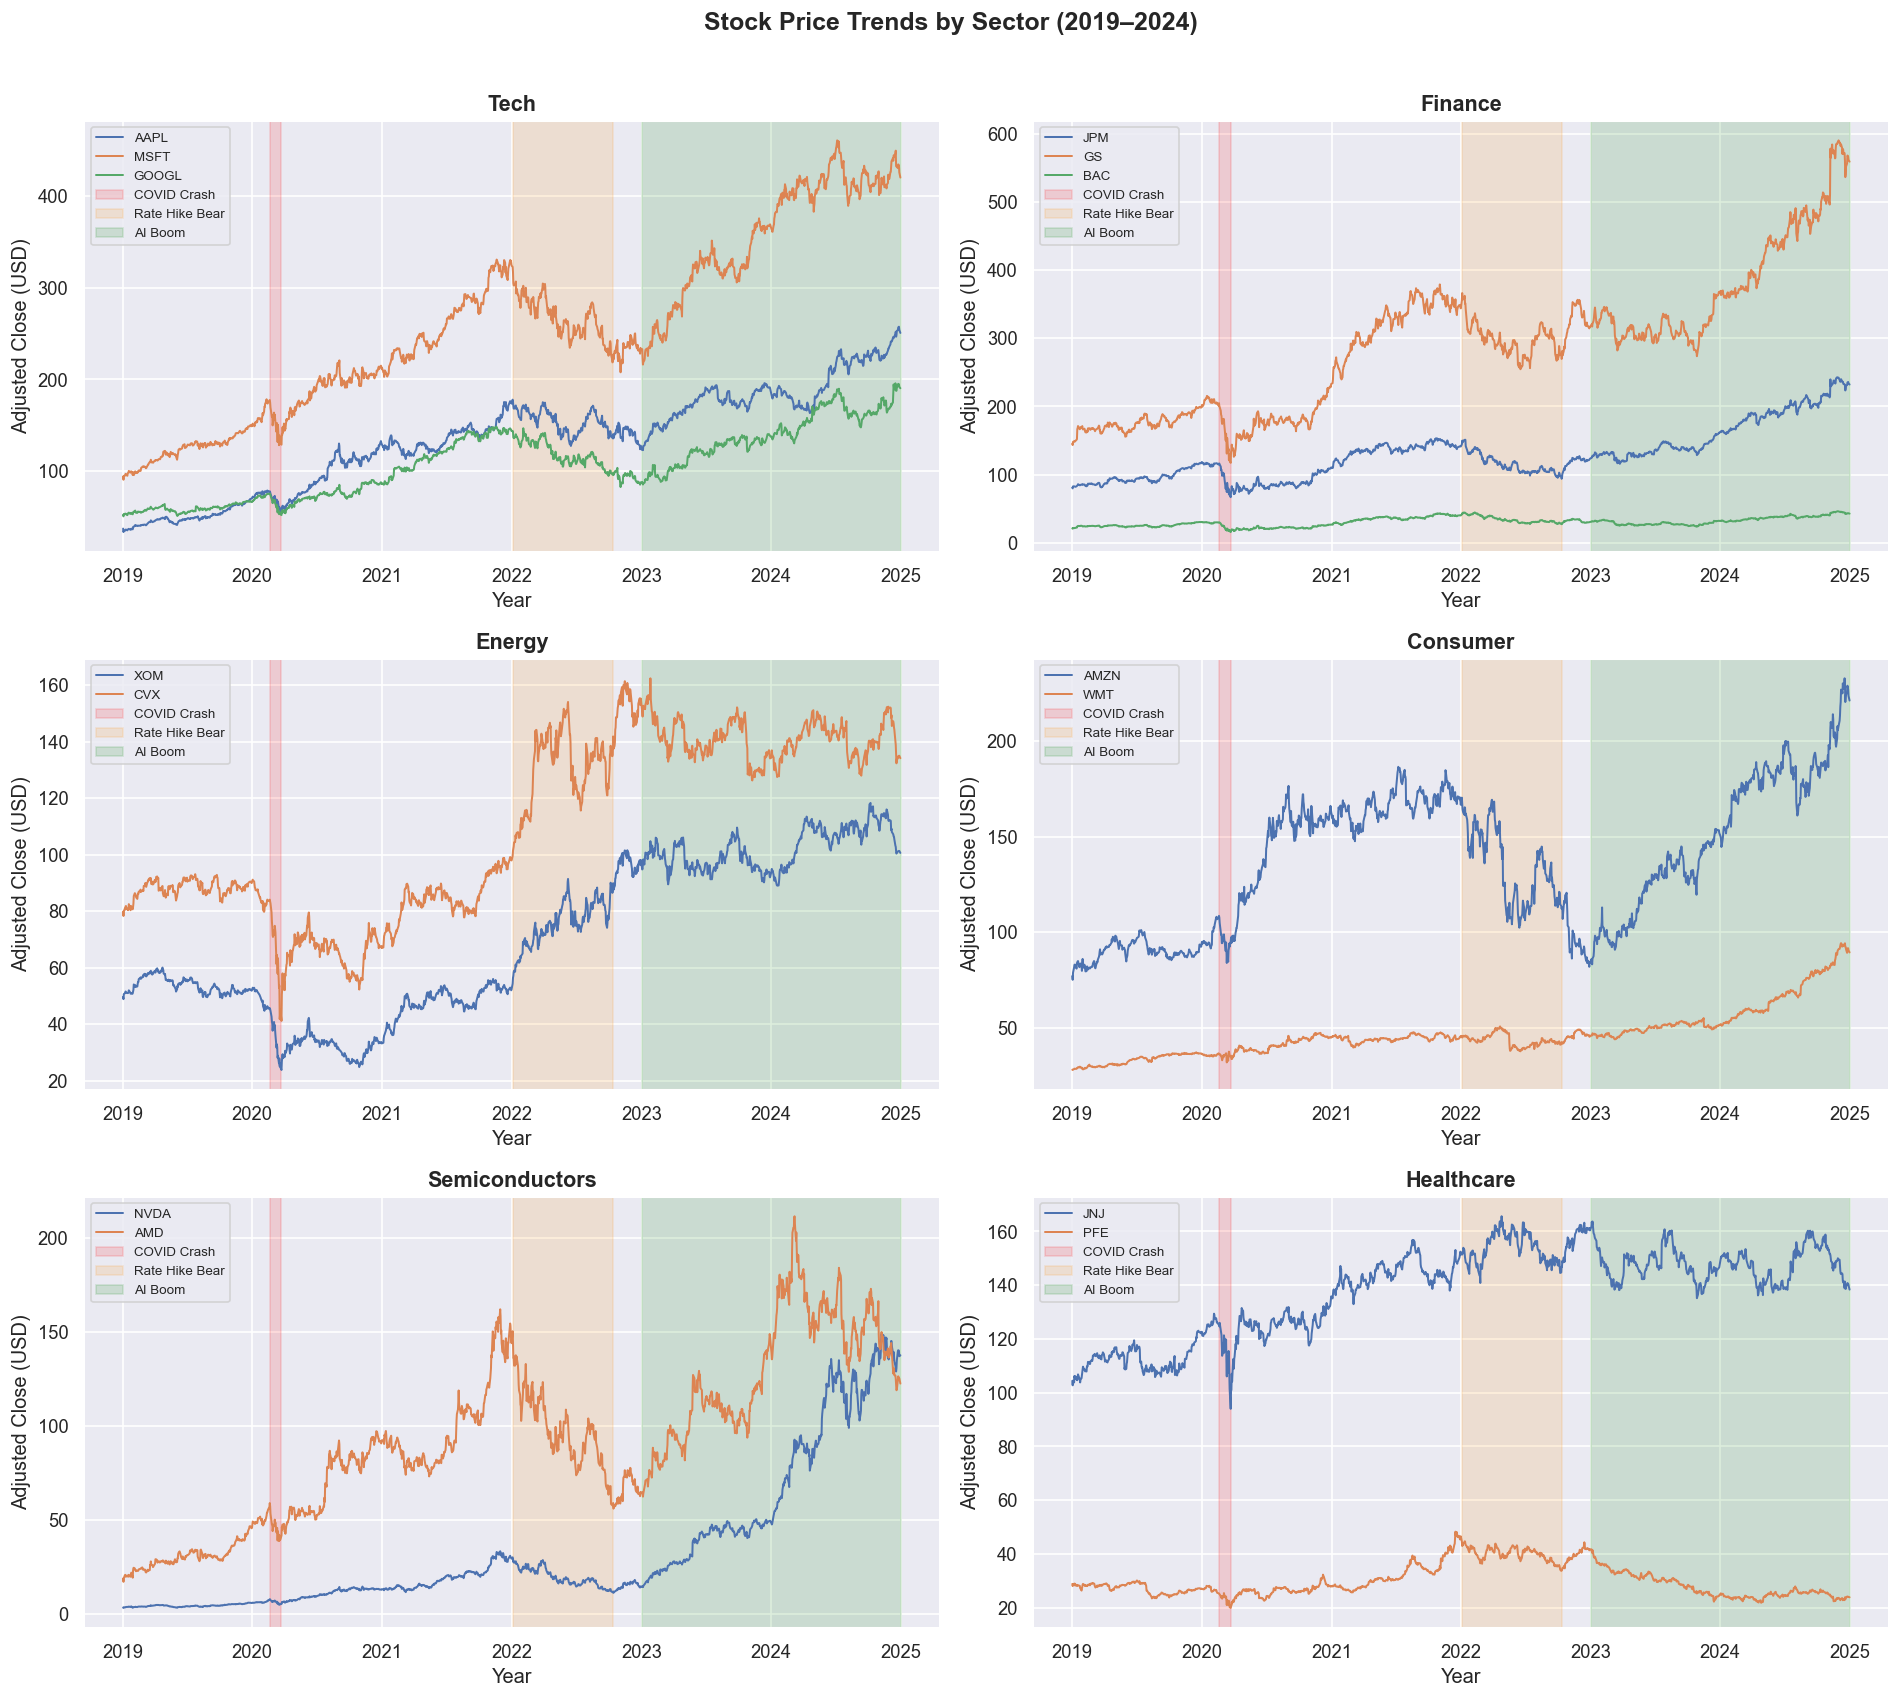

In [8]:
# market regimes
regimes = [
    ("2020-02-19", "2020-03-23", "COVID Crash", "#ff000022"),
    ("2022-01-03", "2022-10-12", "Rate Hike Bear", "#ff8c0022"),
    ("2023-01-01", "2024-12-31", "AI Boom", "#00800022"),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (sector, tickers) in enumerate(TICKERS.items()):
    ax = axes[idx]
    
    for ticker in tickers:
        ax.plot(dfs[ticker].index, dfs[ticker]["Close"], label=ticker, linewidth=1.2)
    
    # shade regimes
    for start, end, label, color in regimes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, label=label)
    
    ax.set_title(sector.capitalize(), fontsize=13, fontweight="bold")
    ax.set_ylabel("Adjusted Close (USD)")
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Stock Price Trends by Sector (2019–2024)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}01_price_trends_by_sector.png", bbox_inches="tight")
plt.show()

MSFT was the strongest tech performer over the period. NVDA's trajectory is in a different league post-2023, since it is driven entirely by AI infrastructure demand. Energy was the only sector that held up during the 2022 selloff, while healthcare was essentially flat throughout.

## 2. Return distributions

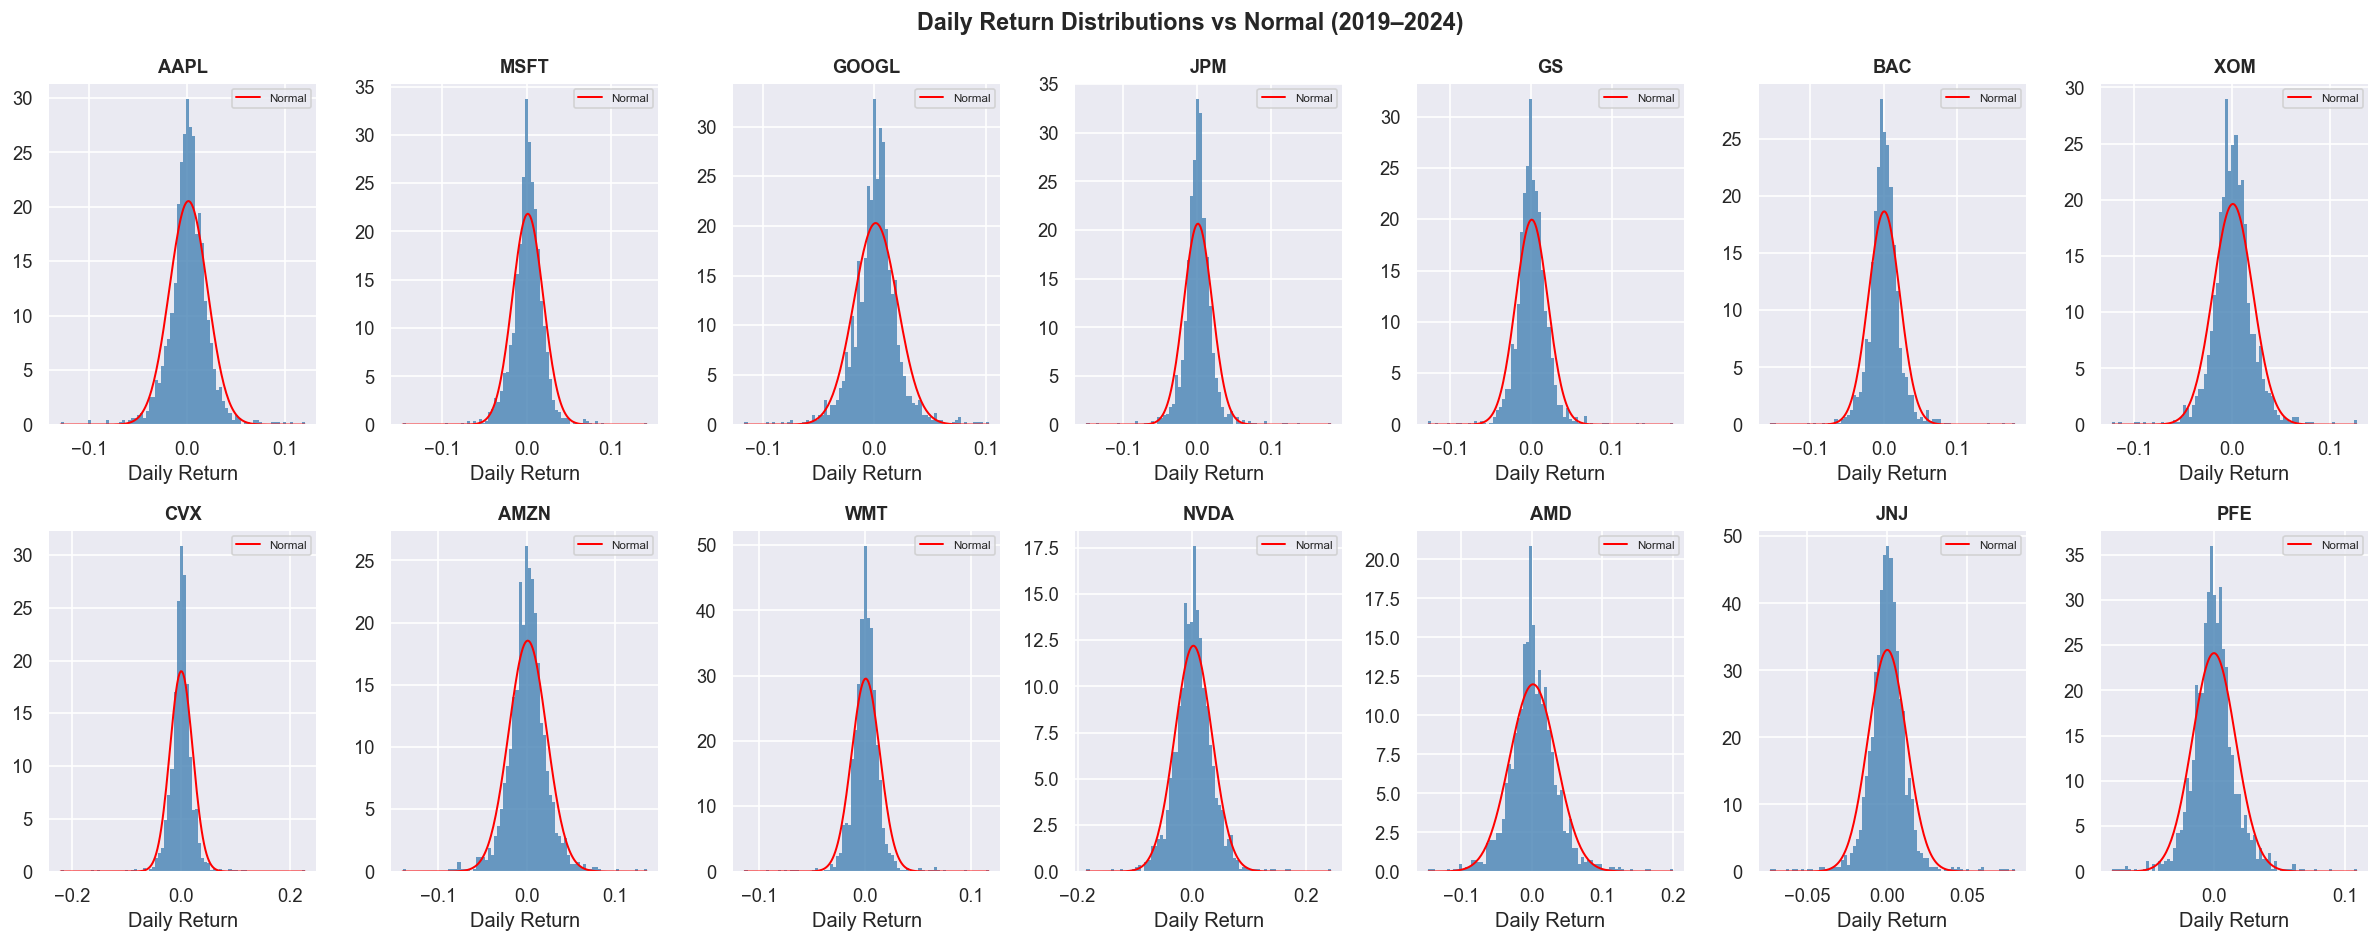

In [12]:
fig, axes = plt.subplots(2, 7, figsize=(20, 8))
axes = axes.flatten()
for idx, ticker in enumerate(ALL_TICKERS):
    ax = axes[idx]
    returns = dfs[ticker]["Close"].pct_change().dropna()
    
    ax.hist(returns, bins=80, color="steelblue", edgecolor="none", alpha=0.8, density=True)
    
    # overlay normal distribution for comparison
    mu, std = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 200)
    normal_curve = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / std) ** 2)
    ax.plot(x, normal_curve, color="red", linewidth=1.2, label="Normal")
    
    ax.set_title(ticker, fontsize=11, fontweight="bold")
    ax.set_xlabel("Daily Return")
    ax.legend(fontsize=7)

plt.suptitle("Daily Return Distributions vs Normal (2019–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}02_return_distributions.png", bbox_inches="tight")
plt.show()

Every ticker shows a taller peak than the normal curve with heavier tails. Extreme daily moves happen more often than a normal distribution 
predicts. This directly violates ARIMA's error normality assumption, which is one of the reasons I think using ARIMA here isn't the best choice.

## 3. 30 days rolling volatility

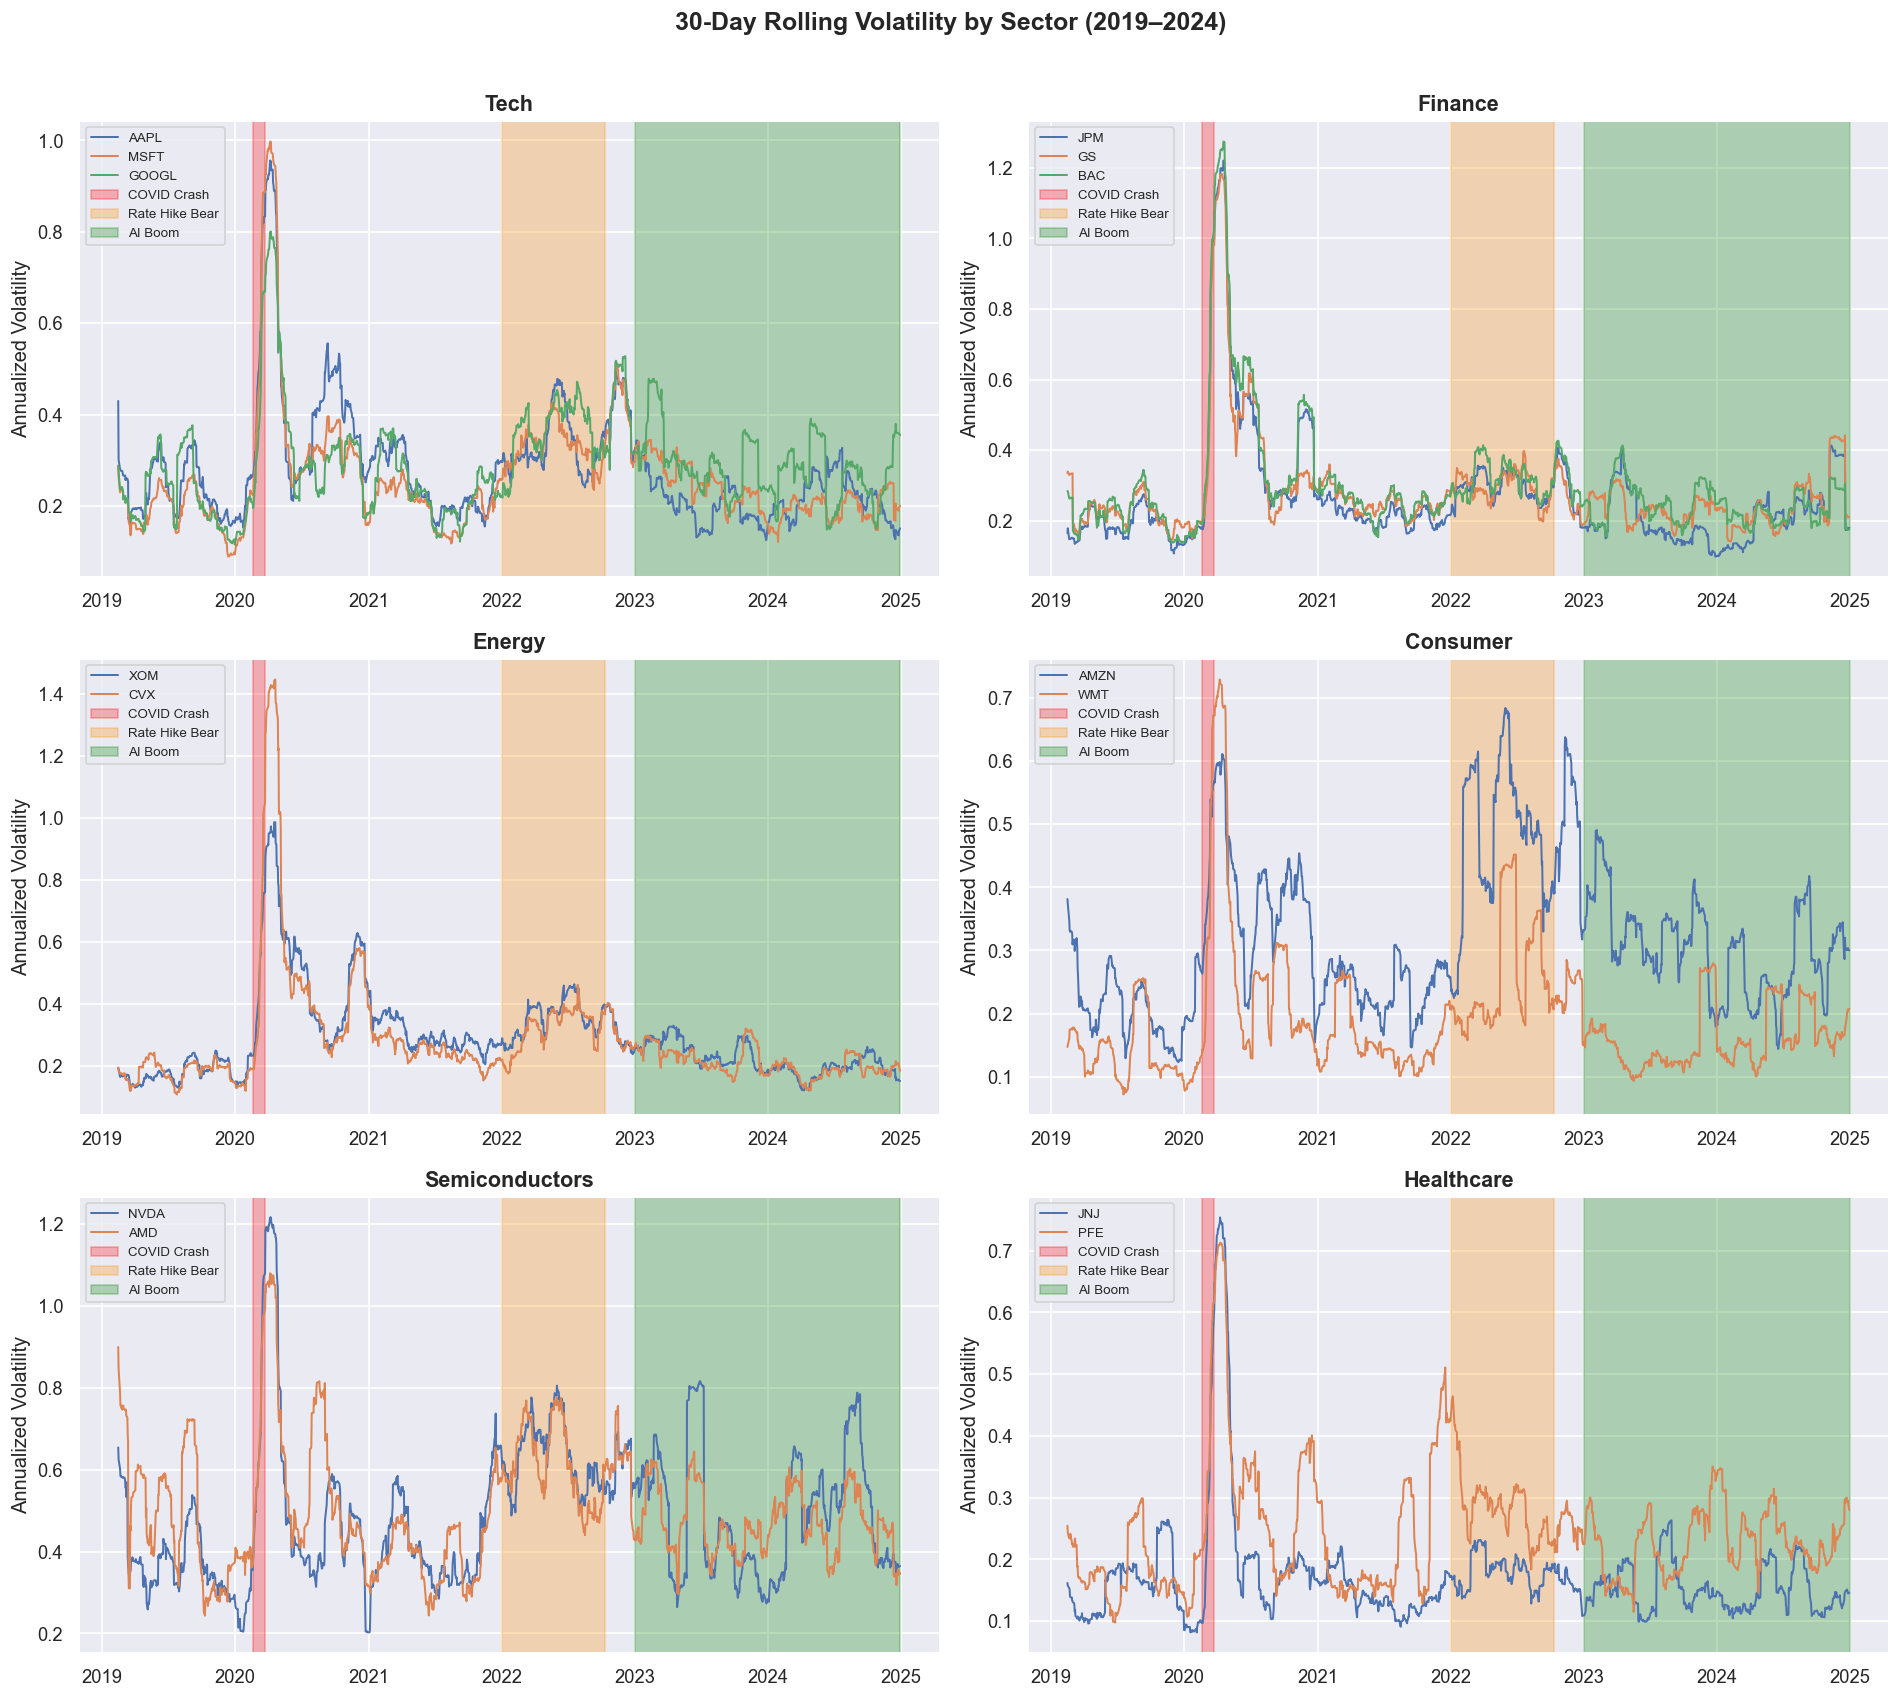

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

regimes = [
    ("2020-02-19", "2020-03-23", "#ff000044", "COVID Crash"),
    ("2022-01-03", "2022-10-12", "#ff8c0044", "Rate Hike Bear"),
    ("2023-01-01", "2024-12-31", "#00800044", "AI Boom"),
]

for idx, (sector, tickers) in enumerate(TICKERS.items()):
    ax = axes[idx]
    
    for ticker in tickers:
        returns = dfs[ticker]["Close"].pct_change()
        rolling_vol = returns.rolling(window=30).std() * np.sqrt(252)
        ax.plot(dfs[ticker].index, rolling_vol, label=ticker, linewidth=1.2)
    
    for start, end, color, label in regimes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color)
    
    patches = [
        mpatches.Patch(color="#ff000044", label="COVID Crash"),
        mpatches.Patch(color="#ff8c0044", label="Rate Hike Bear"),
        mpatches.Patch(color="#00800044", label="AI Boom"),
    ]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + patches, fontsize=8)
    
    ax.set_title(sector.capitalize(), fontsize=13, fontweight="bold")
    ax.set_ylabel("Annualized Volatility")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("30-Day Rolling Volatility by Sector (2019–2024)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}03_rolling_volatility.png", bbox_inches="tight")
plt.show()

COVID spiked volatility across every sector almost instantly. Semiconductors stayed elevated the longest and never really settled back down the way tech or finance did. Healthcare was the most stable throughout.

## 4. Correlation heatmap

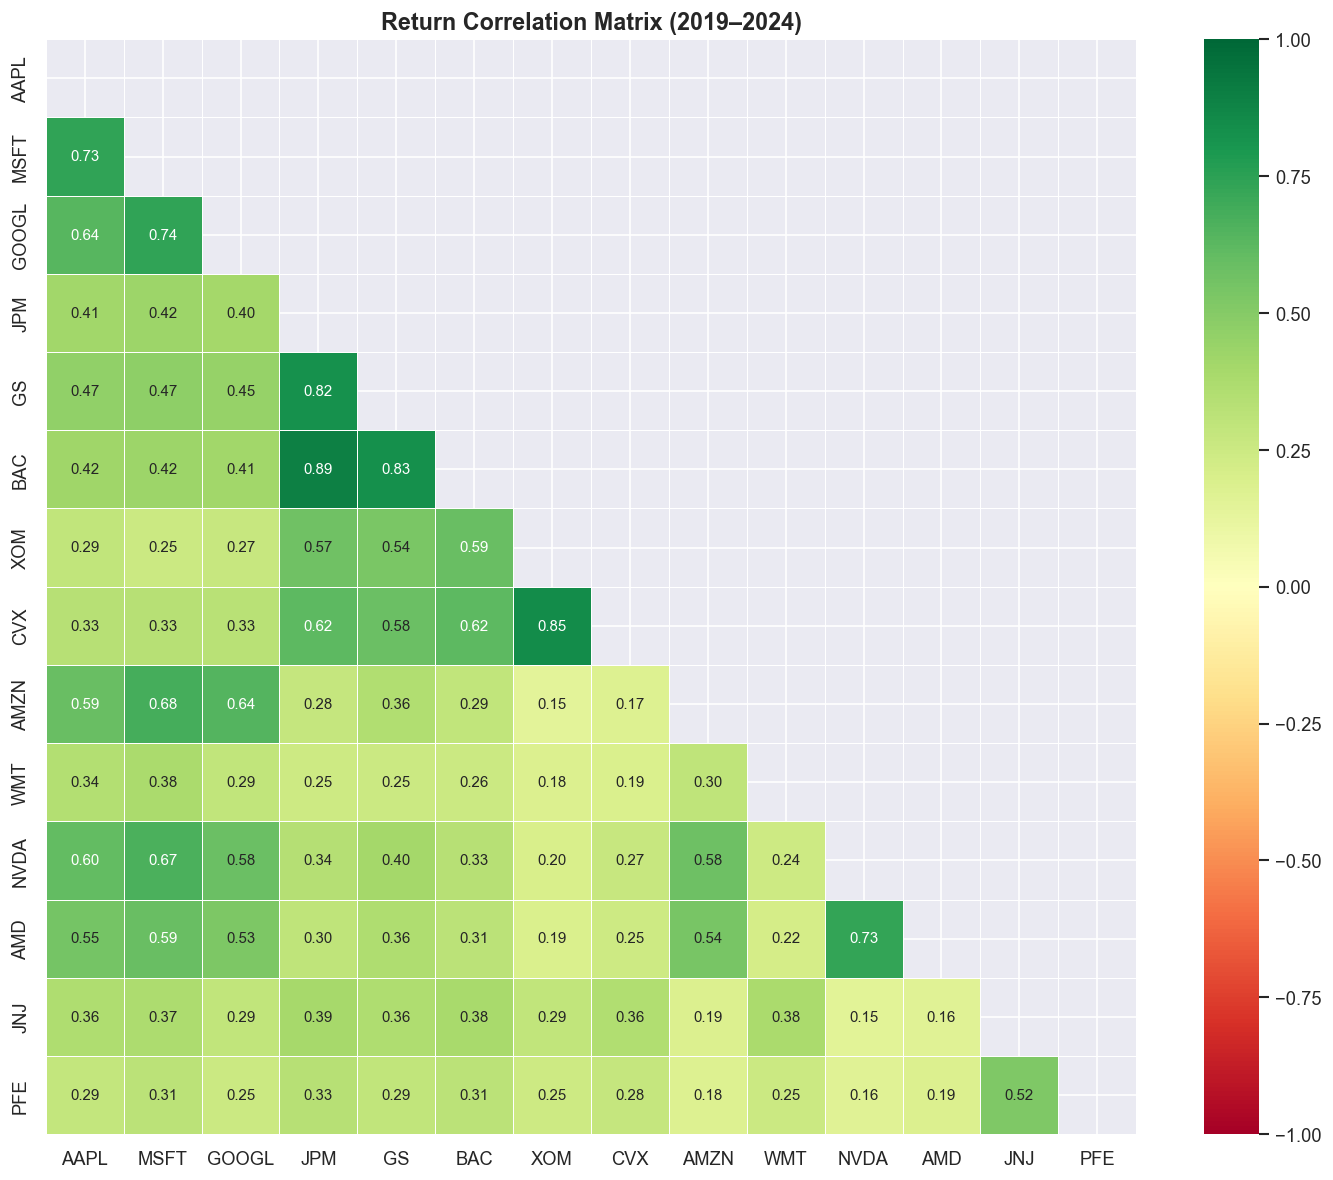

In [20]:
returns_df = pd.DataFrame({
    ticker: dfs[ticker]["Close"].pct_change() for ticker in ALL_TICKERS
}).dropna()

corr = returns_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # mask upper triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title("Return Correlation Matrix (2019–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

We can see finance stocks move together the most. JPM, GS, and BAC are nearly identical in their daily moves. Energy and tech are the most different from each other. Nothing is negatively correlated, so there's no natural hedge in this universe.

## 5. Volume analysis

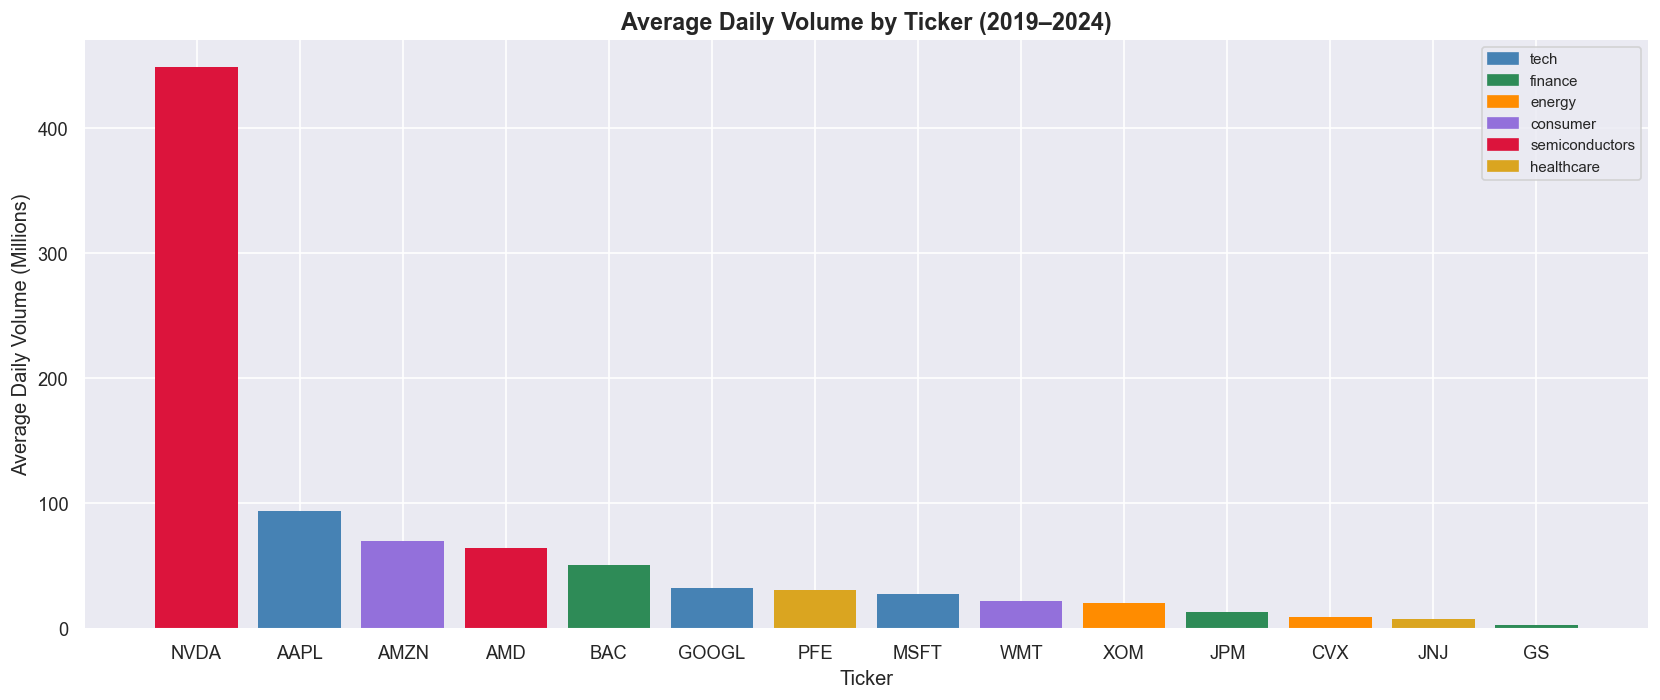

In [22]:
avg_volume = {ticker: dfs[ticker]["Volume"].mean() for ticker in ALL_TICKERS}
avg_volume = pd.Series(avg_volume).sort_values(ascending=False)

sector_colors = {
    "tech": "steelblue",
    "finance": "seagreen",
    "energy": "darkorange",
    "consumer": "mediumpurple",
    "semiconductors": "crimson",
    "healthcare": "goldenrod"
}

colors = []
for ticker in avg_volume.index:
    for sector, tickers in TICKERS.items():
        if ticker in tickers:
            colors.append(sector_colors[sector])

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(avg_volume.index, avg_volume.values / 1e6, color=colors, edgecolor="none")

ax.set_title("Average Daily Volume by Ticker (2019–2024)", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Daily Volume (Millions)")
ax.set_xlabel("Ticker")

patches = [mpatches.Patch(color=color, label=sector) for sector, color in sector_colors.items()]
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}05_volume_analysis.png", bbox_inches="tight")
plt.show()

NVDA is traded way more than anything else here. GS barely moves in comparison. The more a stock is traded, the easier it is to actually buy or sell based on what the model says.

## 6. Monthly seasonality

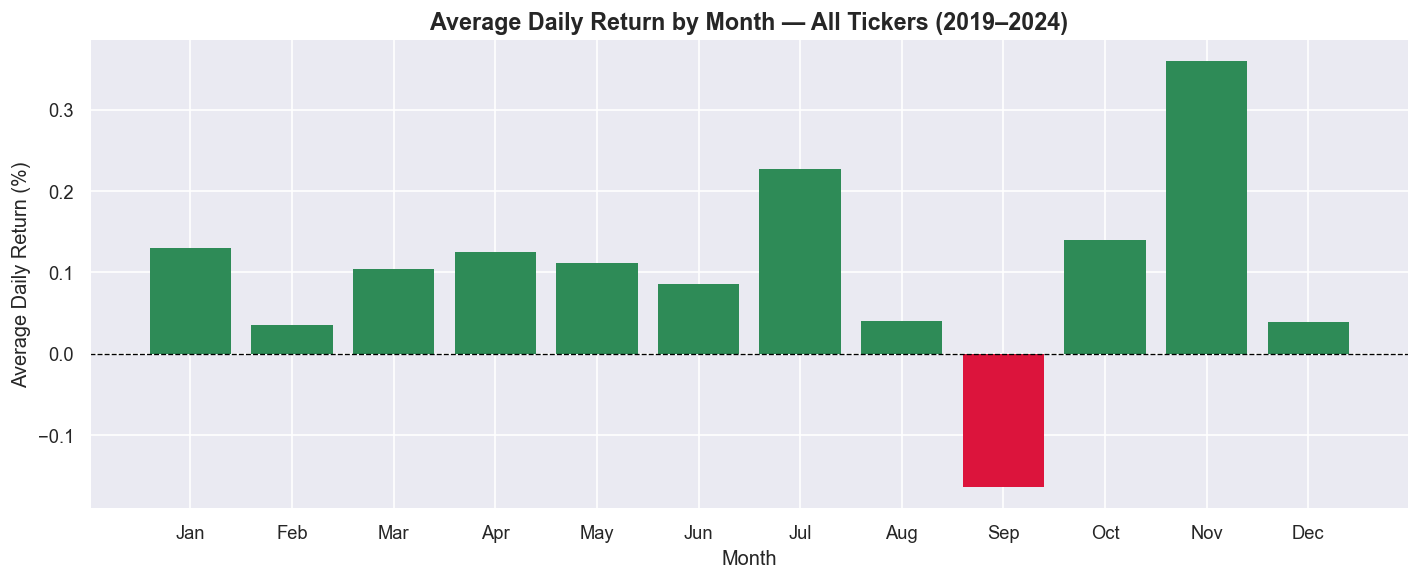

In [23]:
monthly_returns = []

for ticker in ALL_TICKERS:
    df = dfs[ticker].copy()
    df["return"] = df["Close"].pct_change()
    df["month"] = df.index.month
    monthly_returns.append(df[["month", "return"]])

monthly_df = pd.concat(monthly_returns)
monthly_avg = monthly_df.groupby("month")["return"].mean() * 100

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

colors = ["seagreen" if x > 0 else "crimson" for x in monthly_avg]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(month_names, monthly_avg.values, color=colors, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Average Daily Return by Month — All Tickers (2019–2024)", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Daily Return (%)")
ax.set_xlabel("Month")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}06_monthly_seasonality.png", bbox_inches="tight")
plt.show()

## 7. Risk vs Return

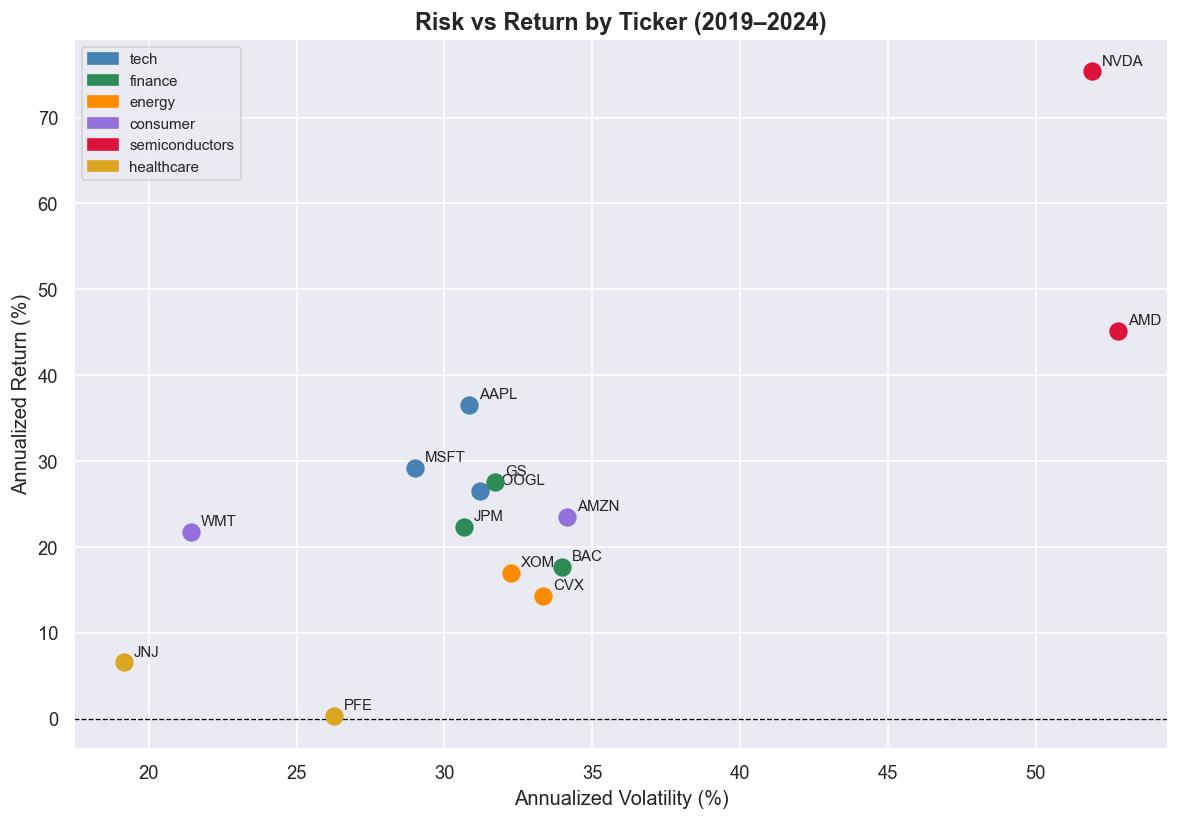

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))

for ticker in ALL_TICKERS:
    returns = dfs[ticker]["Close"].pct_change().dropna()
    ann_return = returns.mean() * 252 * 100
    ann_vol = returns.std() * np.sqrt(252) * 100
    
    for sector, tickers in TICKERS.items():
        if ticker in tickers:
            color = sector_colors[sector]
    
    ax.scatter(ann_vol, ann_return, color=color, s=100, zorder=5)
    ax.annotate(ticker, (ann_vol, ann_return), textcoords="offset points", 
                xytext=(6, 4), fontsize=9)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("Risk vs Return by Ticker (2019–2024)", fontsize=14, fontweight="bold")

patches = [mpatches.Patch(color=color, label=sector) for sector, color in sector_colors.items()]
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}07_risk_return.png", bbox_inches="tight")
plt.show()

NVDA had the highest return but also the highest risk with a lot of volatility. WMT and JNJ gave decent returns with much less risk. PFE is the worst outcome with almost zero return over 5 years with meaningful volatility. This chart is useful context for interpreting model performance by ticker later.

## Key Findings

- All 14 tickers have non stationary prices but stationary returns, so we model returns throughout.
- Fat tails across every ticker shows that extreme daily moves are more common than a normal distribution predicts.
- After volatility spikes during COVID and 2022, semiconductors never fully calm down.
- Finance stocks move almost identically, energy and tech are the most uncorrelated pair.
- September is the only consistently negative month, November is the strongest.
- NVDA highest return and highest risk, PFE near zero return for moderate risk.